### Filtering of flames according to attached/detached classification and flame type

#### Importing Libraries

In [ ]:
# Sys
import os
import sys
import json
sys.path.append("..")

# Data
import pandas as pd
import numpy as np
import shap
shap.initjs() 
import joblib
import importlib
from src import path
importlib.reload(path)
from src.path import PATH_DATASETV1, PATH_DATA_FLAMELENGTH, PATH_DATA_FLAMELENGTH_NEW, PATH_FLAMELENGTH_FOLDER, PATH_DATA_FLAMELENGTH_MERGED

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, ShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct, RBF

from sklearn.metrics import mean_squared_error, r2_score

# plotting defaults
%matplotlib inline

In [2]:
def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

#### Merge labels in DatasetV1.xlsx to DatasetFLameComplet.xlsx

In [ ]:
# df_datasetv1 = pd.read_excel(PATH_DATASETV1)
# df_flamelength = pd.read_csv(PATH_DATA_FLAMELENGTH_MERGED)

# print("remaining samples in flamelength:", len(df_flamelength))

# # Keys to disambiguate duplicates
# merge_keys = ["J", "S1", "S2", "PhiTot", "PhiInt", "u1", "u2"]
# num_keys = ["J", "S1", "S2", "PhiTot", "PhiInt", "u1", "u2"]
# df_datasetv1[num_keys] = df_datasetv1[num_keys].astype(float).round(3)
# df_flamelength[num_keys] = df_flamelength[num_keys].astype(float).round(3)

# # Only add these columns from datasetv1
# cols_to_add = ["Attache (I/O)", "Groupe", "Type"]

# # Remove duplicates from datasetv1, keep first occurrence
# df_datasetv1_dedup = df_datasetv1.drop_duplicates(subset=merge_keys, keep="first")

# df_merged = pd.merge(
#     df_flamelength,
#     df_datasetv1_dedup[merge_keys + cols_to_add],
#     on=merge_keys,
#     how="left",
# )


# # ---- 1-to-1 validation summary ----
# dup_left = df_flamelength.duplicated(subset=merge_keys, keep=False).sum()
# dup_right = df_datasetv1_dedup.duplicated(subset=merge_keys, keep=False).sum()
# unmatched = df_merged[cols_to_add].isna().all(axis=1).sum()

# is_one_to_one = (dup_left == 0) and (dup_right == 0) and (unmatched == 0)

# print(f"Duplicate keys in flamelength: {dup_left}")
# print(f"Duplicate keys in datasetv1: {dup_right}")
# print(f"Unmatched rows after merge: {unmatched}")
# print(f"1-to-1 merge achieved: {is_one_to_one}")


# # save
# output_path = os.path.join(PATH_FLAMELENGTH_FOLDER, "flamelength_with_labels.csv")
# df_merged.to_csv(output_path, index=False)
# print(f"Saved to {output_path}")

# # Save rows from flamelength that did not match (labels are NaN)
# unmatched_rows = df_merged[df_merged[cols_to_add].isna().all(axis=1)]
# unmatched_path = os.path.join(PATH_FLAMELENGTH_FOLDER, "flamelength_unmatched.csv")
# unmatched_rows.to_csv(unmatched_path, index=False)
# print(f"Saved unmatched rows to {unmatched_path}")

# df_flamelength_labels = pd.read_csv(os.path.join(PATH_FLAMELENGTH_FOLDER, "flamelength_with_labels.csv"))

# # Remove rows with missing Attache (I/O)
# df_filtered = df_flamelength_labels.dropna(subset=['Attache (I/O)'])


# # Keep only attached flames (Attache (I/O) == 1)
# df_filtered = df_filtered[df_filtered['Attache (I/O)'] == 1]

# print("Remaining samples:", len(df_filtered))

# # Keep only Type == 1
# df_filtered = df_filtered[df_filtered['Type'] =='I']

# print(f"Remaining samples: {len(df_filtered)}")

#### Test for individual S1 values (0.0 and +0.29) & remove outliers

initial samples: 187
remaining samples: 2
beta0 = 6.957348200859145
beta1 = 1.527607141258608
beta2 = 0.9154204912084744
R² of fitted model = 1.0
Outliers detected (>1σ): 1, but capping at 10% = 0
Samples: 2 → 2 (removed 0)

--- After outlier removal ---
beta0 = 6.957348200859145
beta1 = 1.527607141258608
beta2 = 0.9154204912084744
R² of fitted model = 1.0


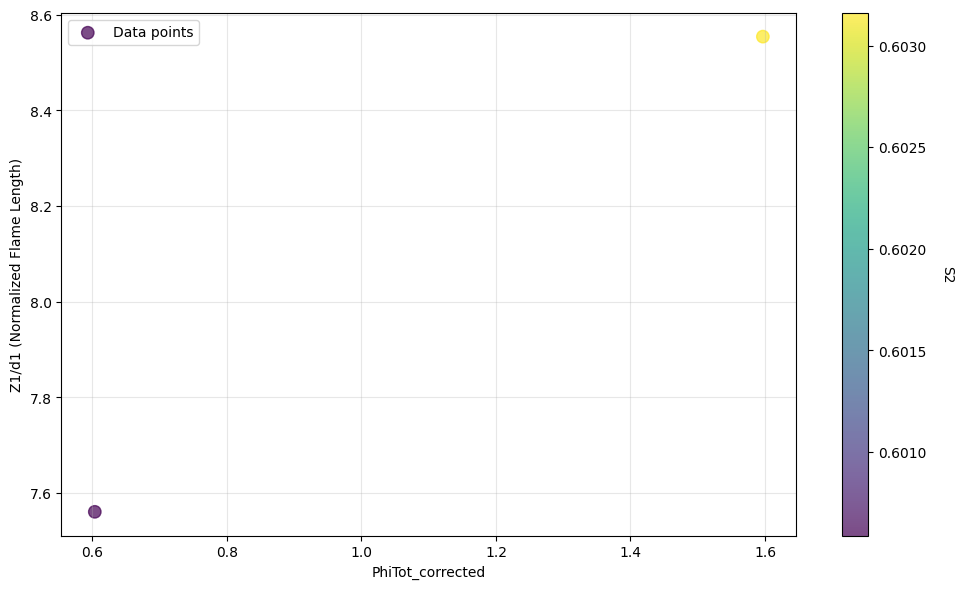

k from global model (S1=0,0.29): -2.5700
k implied by S1=0.86 β₁: -1.1347
k implied by S1=0.86 β₂: -1.1781

β₀ from global: 6.9573
β₀ from S1=0.86: 6.9570
Difference: 0.0003


In [ ]:
df = pd.read_csv(PATH_DATA_FLAMELENGTH_MERGED)
print("initial samples:", len(df))

df = df[
    np.isclose(df["PhiInt_rescaled"], 1.0, atol=0.01)
    & (
        np.isclose(df["S1"], 0.87, atol=0.1)
        #    | np.isclose(df["S1"], 0.29, atol=0.1)
    )
]

print("remaining samples:", len(df))

# Load data
y = df["Z1/d1"].to_numpy()
phitot = df["PhiTot"].to_numpy()
s2 = df["S2"].to_numpy()

# Fit model: y = beta0 + beta1*PhiTot + beta2*PhiTot*S2
X = np.column_stack(
    [
        np.ones_like(phitot),
        phitot,
        phitot * s2,
    ]
)

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
beta0, beta1, beta2 = beta

print("beta0 =", beta0)
print("beta1 =", beta1)
print("beta2 =", beta2)

PhiTot_mod = beta1 * phitot + beta2 * phitot * s2
y_shifted = y - beta0

# Predict using the fitted model
y_pred = beta0 + beta1 * phitot + beta2 * phitot * s2

# Compute R²
residuals = y - y_pred
r2 = 1 - np.sum(residuals**2) / np.sum((y - y.mean()) ** 2)
print("R² of fitted model =", r2)

# ===== Remove outliers (>1σ) with 10% cap =====
outlier_threshold = 1 * residuals.std()
outlier_mask = np.abs(residuals) > outlier_threshold
n_outliers_detected = outlier_mask.sum()
max_removable = int(0.1 * len(df))  # 10% of samples

if n_outliers_detected > max_removable:
    # If more outliers detected than allowed, keep only the worst 10%
    residual_abs = np.abs(residuals)
    sorted_indices = np.argsort(residual_abs)[::-1]  # Sort descending
    outlier_indices = sorted_indices[:max_removable]
    outlier_mask = np.zeros(len(df), dtype=bool)
    outlier_mask[outlier_indices] = True
    n_outliers = max_removable
    print(
        f"Outliers detected (>1σ): {n_outliers_detected}, but capping at 10% = {max_removable}"
    )
else:
    n_outliers = n_outliers_detected
    print(f"Outliers detected (>1σ): {n_outliers}")

# Remove outliers
df = df[~outlier_mask].reset_index(drop=True)
y = y[~outlier_mask]
phitot = phitot[~outlier_mask]
s2 = s2[~outlier_mask]

print(f"Samples: {len(df) + n_outliers} → {len(df)} (removed {n_outliers})")

# ===== Refit model on clean data =====
X = np.column_stack(
    [
        np.ones_like(phitot),
        phitot,
        phitot * s2,
    ]
)

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
beta0, beta1, beta2 = beta

print(f"\n--- After outlier removal ---")
print("beta0 =", beta0)
print("beta1 =", beta1)
print("beta2 =", beta2)

PhiTot_mod = beta1 * phitot + beta2 * phitot * s2
y_shifted = y - beta0

y_pred = beta0 + beta1 * phitot + beta2 * phitot * s2
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
print("R² of fitted model =", r2)

df["PhiTot_corrected"] = PhiTot_mod

# Visualize the regression fit
plt.figure(figsize=(10, 6))

# Plot scatter: actual data points colored by S2
scatter = plt.scatter(
    PhiTot_mod, y, c=s2, cmap="viridis", alpha=0.7, s=80, label="Data points"
)
plt.xlabel("PhiTot_corrected")
plt.ylabel("Z1/d1 (Normalized Flame Length)")
cbar = plt.colorbar(scatter)
cbar.set_label("S2", rotation=270, labelpad=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Adding back effect of S1

initial samples: 187
remaining samples: 39
beta0 = 6.060931920656471
beta1 = 62.50236294735272
beta2 = -69.15216459859629
k = -2.5896100448411596
R² of fitted model = 0.8516249271752208
Outliers detected (>3σ): 0
Samples: 39 → 39 (removed 0)

--- After outlier removal ---
beta0 = 6.060931920656471
beta1 = 62.50236294735272
beta2 = -69.15216459859629
beta3 = -162.29936646087384
beta4 = 178.5874289863133
k = -2.5896100448411596
R² of fitted model = 0.8516249271752208


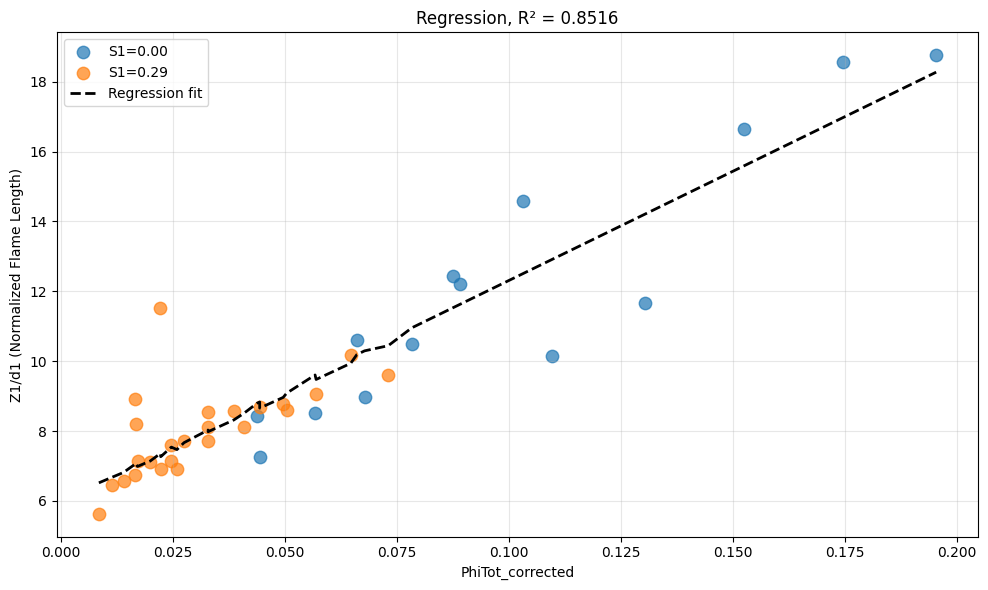

In [120]:
df = pd.read_csv(PATH_DATA_FLAMELENGTH_MERGED)
print("initial samples:", len(df))

df = df[
    np.isclose(df["PhiInt_rescaled"], 1.0, atol=0.1)
    & (np.isclose(df["S1"], 0.00, atol=0.1) | np.isclose(df["S1"], 0.29, atol=0.1))
]

print("remaining samples:", len(df))

# Load data
y = df["Z1/d1"].to_numpy()
phitot = df["PhiTot"].to_numpy()
s1 = df["S1"].to_numpy()
s2 = df["S2"].to_numpy()

# Get unique S1 values and sort them
s1_values = sorted(df["S1"].unique())
# Assign distinct colors to each S1 value
distinct_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
]
s1_colors = distinct_colors[: len(s1_values)]

# Fit the full model:
# y = beta0 + beta1*PhiTot + beta2*PhiTot*S2 + beta3*PhiTot*S1 + beta4*PhiTot*S1*S2
# Model: y = beta0 + (1 + k·S1) · (beta1·PhiTot + beta2·PhiTot·S2)
# Reparametrize: beta3 = k·beta1, beta4 = k·beta2
X = np.column_stack(
    [
        np.ones_like(phitot),
        phitot,
        phitot * s2,
        phitot * s1,
        phitot * s1 * s2,
    ]
)

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
beta0, beta1, beta2, beta3, beta4 = beta

# Recover k from the average of beta3/beta1 and beta4/beta2
k = 0.5 * (beta3 / beta1 + beta4 / beta2)

print("beta0 =", beta0)
print("beta1 =", beta1)
print("beta2 =", beta2)
print("k =", k)

# Build modified PhiTot
PhiTot_mod = (1 + k * s1) * phitot * (1 + (beta2 / beta1) * s2)

# Predict using the fitted model
y_pred = (
    beta0
    + beta1 * phitot
    + beta2 * phitot * s2
    + beta3 * phitot * s1
    + beta4 * phitot * s1 * s2
)

# Compute R²
residuals = y - y_pred
r2 = 1 - np.sum(residuals**2) / np.sum((y - y.mean()) ** 2)
print("R² of fitted model =", r2)

# ===== Remove outliers (>3σ) with 10% cap =====
outlier_threshold = 5 * residuals.std()
outlier_mask = np.abs(residuals) > outlier_threshold
n_outliers_detected = outlier_mask.sum()
max_removable = int(0.1 * len(df))  # 10% of samples

if n_outliers_detected > max_removable:
    residual_abs = np.abs(residuals)
    sorted_indices = np.argsort(residual_abs)[::-1]
    outlier_indices = sorted_indices[:max_removable]
    outlier_mask = np.zeros(len(df), dtype=bool)
    outlier_mask[outlier_indices] = True
    n_outliers = max_removable
    print(
        f"Outliers detected (>3σ): {n_outliers_detected}, but capping at 10% = {max_removable}"
    )
else:
    n_outliers = n_outliers_detected
    print(f"Outliers detected (>3σ): {n_outliers}")

# Remove outliers
df = df[~outlier_mask].reset_index(drop=True)
y = y[~outlier_mask]
phitot = phitot[~outlier_mask]
s1 = s1[~outlier_mask]
s2 = s2[~outlier_mask]

print(f"Samples: {len(df) + n_outliers} → {len(df)} (removed {n_outliers})")

# ===== Refit model on clean data =====
X = np.column_stack(
    [
        np.ones_like(phitot),
        phitot,
        phitot * s2,
        phitot * s1,
        phitot * s1 * s2,
    ]
)

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
beta0, beta1, beta2, beta3, beta4 = beta

print(f"\n--- After outlier removal ---")
print("beta0 =", beta0)
print("beta1 =", beta1)
print("beta2 =", beta2)
print("beta3 =", beta3)
print("beta4 =", beta4)

k = 0.5 * (beta3 / beta1 + beta4 / beta2)
print("k =", k)

PhiTot_mod = (1 + k * s1) * phitot * (1 + (beta2 / beta1) * s2)
y_shifted = y - beta0

y_pred = (
    beta0
    + beta1 * phitot
    + beta2 * phitot * s2
    + beta3 * phitot * s1
    + beta4 * phitot * s1 * s2
)
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
print("R² of fitted model =", r2)

df["PhiTot_corrected"] = PhiTot_mod

# Visualize the regression fit
plt.figure(figsize=(10, 6))

# Plot scatter: actual data points
for i, s1_val in enumerate(s1_values):
    mask = s1 == s1_val
    plt.scatter(
        PhiTot_mod[mask],
        y[mask],
        label=f"S1={s1_val:.2f}",
        color=s1_colors[i],
        alpha=0.7,
        s=80,
    )

# Plot regression line: y_pred vs PhiTot_mod
sort_idx = np.argsort(PhiTot_mod)
plt.plot(
    PhiTot_mod[sort_idx],
    y_pred[sort_idx],
    "k--",
    linewidth=2,
    label="Regression fit",
)

plt.xlabel("PhiTot_corrected")
plt.ylabel("Z1/d1 (Normalized Flame Length)")
plt.title(f"Regression, R² = {r2:.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### with S1 = 0.87

initial samples: 187
remaining samples: 39
beta0 = 6.060931920656471
beta1 = 62.50236294735272
beta2 = -69.15216459859629
beta3 = -162.29936646087384
beta4 = 178.5874289863133
R² of fitted model = 0.8516249271752208
Outliers detected (>3σ): 1
Samples: 39 → 38 (removed 1)

--- After outlier removal ---
beta0 = 5.733462998691956
beta1 = 63.28277179650459
beta2 = -69.51596647831272
beta3 = -162.89652672857903
beta4 = 178.44569501609593
R² of fitted model = 0.8993696853099605


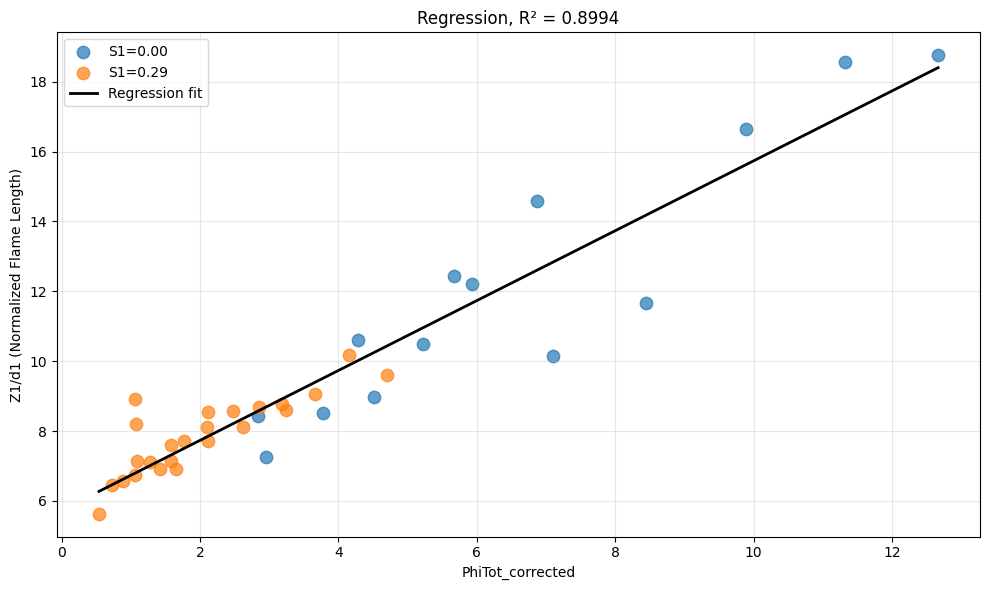

In [123]:
df = pd.read_csv(PATH_DATA_FLAMELENGTH_MERGED)
print("initial samples:", len(df))

df = df[
    np.isclose(df["PhiInt_rescaled"], 1.0, atol=0.1)
    & (
        np.isclose(df["S1"], 0.00, atol=0.1)
        | np.isclose(df["S1"], 0.29, atol=0.1)
        # | np.isclose(df["S1"], 0.87, atol=0.1)
    )
]

print("remaining samples:", len(df))

# Load data
y = df["Z1/d1"].to_numpy()
phitot = df["PhiTot"].to_numpy()
s1 = df["S1"].to_numpy()
s2 = df["S2"].to_numpy()


# Get unique S1 values and sort them
s1_values = sorted(df["S1"].unique())
# Assign distinct colors to each S1 value
distinct_colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
]
s1_colors = distinct_colors[: len(s1_values)]

# Fit the full model:
# y = beta0 + beta1*PhiTot + beta2*PhiTot*S2 + beta3*PhiTot*S1 + beta4*PhiTot*S1*S2
X = np.column_stack(
    [
        np.ones_like(phitot),
        phitot,
        phitot * s2,
        phitot * s1,
        phitot * s1 * s2,
    ]
)

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
beta0, beta1, beta2, beta3, beta4 = beta

print("beta0 =", beta0)
print("beta1 =", beta1)
print("beta2 =", beta2)
print("beta3 =", beta3)
print("beta4 =", beta4)

# Build modified PhiTot
PhiTot_mod = (
    beta1 * phitot
    + beta2 * phitot * s2
    + beta3 * phitot * s1
    + beta4 * phitot * s1 * s2
)

# Predict using the fitted model
y_pred = beta0 + PhiTot_mod

# Compute R²
residuals = y - y_pred
r2 = 1 - np.sum(residuals**2) / np.sum((y - y.mean()) ** 2)
print("R² of fitted model =", r2)

# ===== Remove outliers (>3σ) with 10% cap =====
outlier_threshold = 3 * residuals.std()
outlier_mask = np.abs(residuals) > outlier_threshold
n_outliers_detected = outlier_mask.sum()
max_removable = int(0.1 * len(df))  # 10% of samples

if n_outliers_detected > max_removable:
    residual_abs = np.abs(residuals)
    sorted_indices = np.argsort(residual_abs)[::-1]
    outlier_indices = sorted_indices[:max_removable]
    outlier_mask = np.zeros(len(df), dtype=bool)
    outlier_mask[outlier_indices] = True
    n_outliers = max_removable
    print(
        f"Outliers detected (>3σ): {n_outliers_detected}, but capping at 10% = {max_removable}"
    )
else:
    n_outliers = n_outliers_detected
    print(f"Outliers detected (>3σ): {n_outliers}")

# Remove outliers
df = df[~outlier_mask].reset_index(drop=True)
y = y[~outlier_mask]
phitot = phitot[~outlier_mask]
s1 = s1[~outlier_mask]
s2 = s2[~outlier_mask]

print(f"Samples: {len(df) + n_outliers} → {len(df)} (removed {n_outliers})")

# ===== Refit model on clean data =====
X = np.column_stack(
    [
        np.ones_like(phitot),
        phitot,
        phitot * s2,
        phitot * s1,
        phitot * s1 * s2,
    ]
)

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
beta0, beta1, beta2, beta3, beta4 = beta

print(f"\n--- After outlier removal ---")
print("beta0 =", beta0)
print("beta1 =", beta1)
print("beta2 =", beta2)
print("beta3 =", beta3)
print("beta4 =", beta4)

# Build modified PhiTot
PhiTot_mod = (
    beta1 * phitot
    + beta2 * phitot * s2
    + beta3 * phitot * s1
    + beta4 * phitot * s1 * s2
)
y_shifted = y - beta0

y_pred = beta0 + PhiTot_mod
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
print("R² of fitted model =", r2)

df["PhiTot_corrected"] = PhiTot_mod

# Visualize the regression fit
plt.figure(figsize=(10, 6))

# Plot scatter: actual data points
for i, s1_val in enumerate(s1_values):
    mask = np.isclose(s1, s1_val, atol=0.1)
    plt.scatter(
        PhiTot_mod[mask],
        y[mask],
        label=f"S1={s1_val:.2f}",
        color=s1_colors[i],
        alpha=0.7,
        s=80,
    )

# Plot regression line: y_pred vs PhiTot_mod
sort_idx = np.argsort(PhiTot_mod)
plt.plot(
    PhiTot_mod[sort_idx],
    y_pred[sort_idx],
    "k-",
    linewidth=2,
    label="Regression fit",
)

plt.xlabel("PhiTot_corrected")
plt.ylabel("Z1/d1 (Normalized Flame Length)")
plt.title(
    f"Regression, R² = {r2:.4f}"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df["PhiTot_corrected"] = PhiTot_mod

#### Visualisation

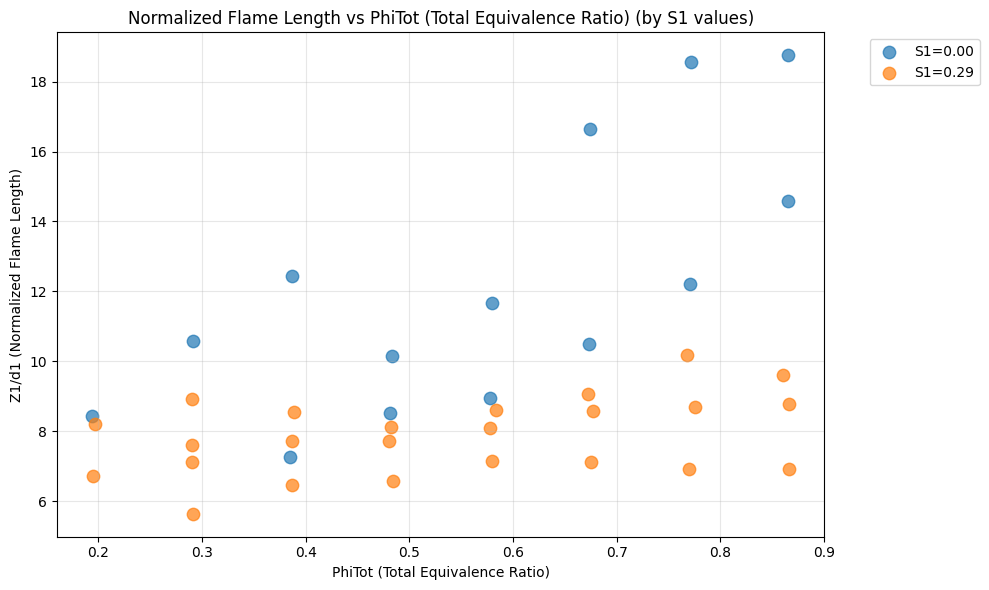

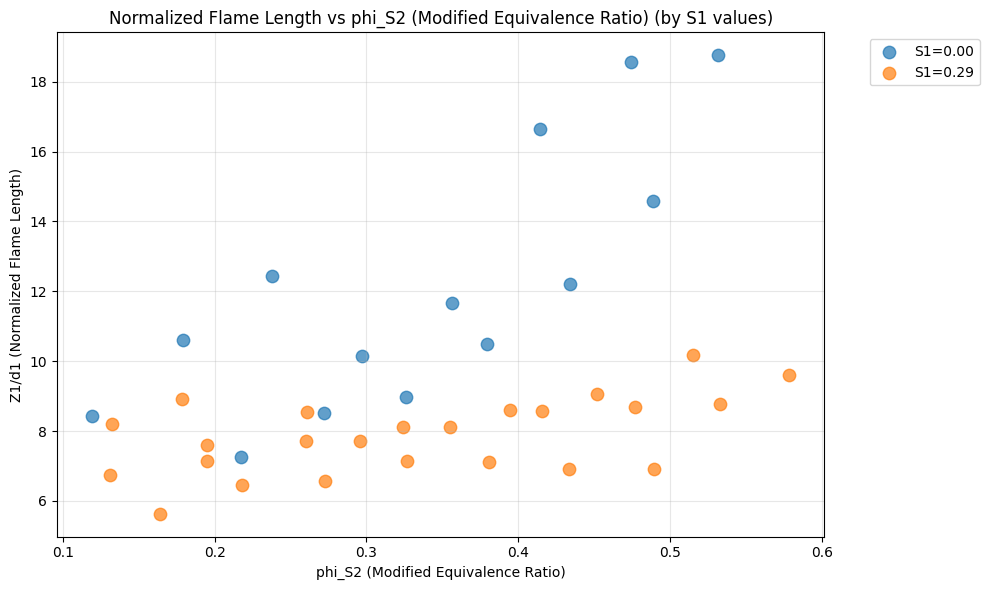

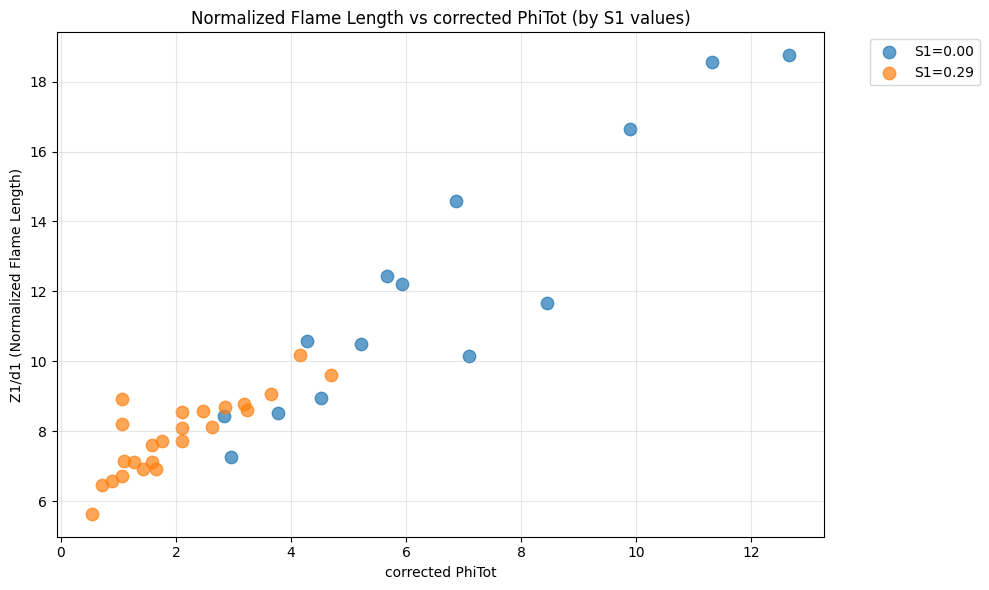

In [ ]:
# Define plots
plot_configs = [
    # ("1/sqrt_J", "1/sqrt(J)"),
    ("PhiTot", "PhiTot (Total Equivalence Ratio)"),
    ("phi_S2", "phi_S2 (Modified Equivalence Ratio)"),
    ("PhiTot_corrected", "corrected PhiTot"),
    # ("S2", "S2"),
]

# Plots colored by S1
for x_col, x_label in plot_configs:
    plt.figure(figsize=(10, 6))
    for i, s1_val in enumerate(s1_values):
        mask = df["S1"] == s1_val
        plt.scatter(
            df[mask][x_col],
            df[mask]["Z1/d1"],
            label=f"S1={s1_val:.2f}",
            color=s1_colors[i],
            alpha=0.7,
            s=80,
        )
    plt.xlabel(x_label)
    plt.ylabel("Z1/d1 (Normalized Flame Length)")
    plt.title(f"Normalized Flame Length vs {x_label} (by S1 values)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# # Plots colored by PhiInt_rescaled (continuous colormap)
# for x_col, x_label in plot_configs:
#     plt.figure(figsize=(10, 6))
#     scatter = plt.scatter(df[x_col], df["Z1/d1"],
#                          c=df["PhiInt_rescaled"], cmap='RdBu_r',
#                          alpha=0.7, s=80, vmin=df["PhiInt_rescaled"].min(),
#                          vmax=df["PhiInt_rescaled"].max())
#     plt.xlabel(x_label)
#     plt.ylabel("Z1/d1 (Normalized Flame Length)")
#     plt.title(f"Normalized Flame Length vs {x_label} (by PhiInt_rescaled)")
#     cbar = plt.colorbar(scatter)
#     cbar.set_label("PhiInt_rescaled", rotation=270, labelpad=20)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#### Load all data

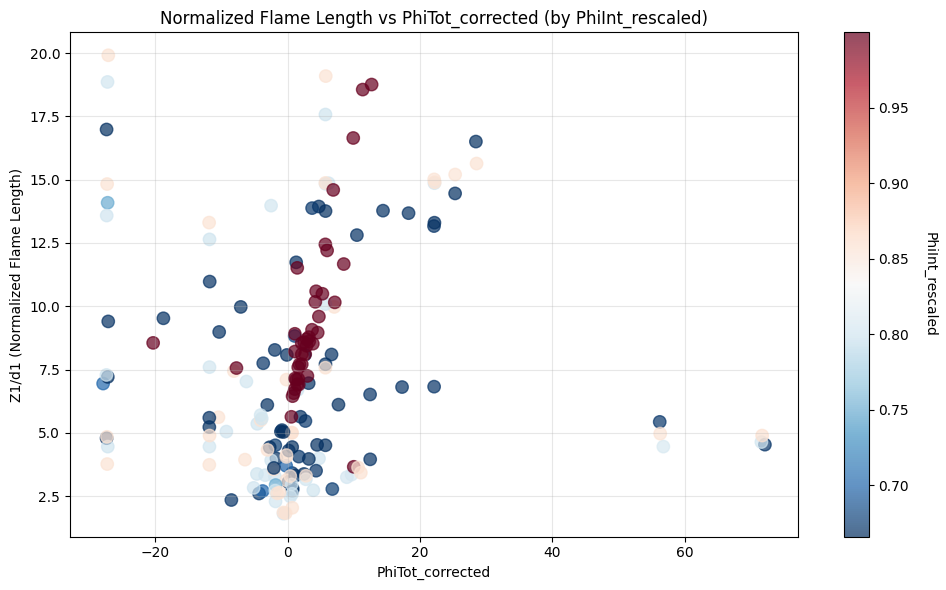

In [113]:
df = pd.read_csv(PATH_DATA_FLAMELENGTH_MERGED)

beta0 = 5.733462998691956
beta1 = 63.28277179650459
beta2 = -69.51596647831272
beta3 = -162.89652672857903
beta4 = 178.44569501609593

df["PhiTot_corrected"] = (
    beta1 * df["PhiTot"]
    + beta2 * df["PhiTot"] * df["S2"]
    + beta3 * df["PhiTot"] * df["S1"]
    + beta4 * df["PhiTot"] * df["S1"] * df["S2"]
)

# Plot Z1/d1 against Phi_corrected, colored by PhiInt_rescaled
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["PhiTot_corrected"],
    df["Z1/d1"],
    c=df["PhiInt_rescaled"],
    cmap="RdBu_r",
    alpha=0.7,
    s=80,
    vmin=df["PhiInt_rescaled"].min(),
    vmax=df["PhiInt_rescaled"].max(),
)
plt.xlabel("PhiTot_corrected")
plt.ylabel("Z1/d1 (Normalized Flame Length)")
plt.title("Normalized Flame Length vs PhiTot_corrected (by PhiInt_rescaled)")
cbar = plt.colorbar(scatter)
cbar.set_label("PhiInt_rescaled", rotation=270, labelpad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Feature selection

In [124]:
# feature and target selection
features = [
    "PhiInt_rescaled",
    "S1",
    "S2",
    "d1",
    "d2",
    "u1",
    "u2",
    "Chamber_Binary",
    "DeltaU",
    "u2/u1",
    "S2/S1",
    "DeltaS",
]

features = [
    "S1",
    "S2",
    "PhiTot",
]

features = [
    "PhiTot_corrected",
    "S1",
    "S2",
]

target = "Z1/d1"  # FlameLength

X = df[features].copy()
y = df[target].copy()
print("Z1/d1 min:", y.min())
print("Z1/d1 max:", y.max())

print("Feature matrix shape:", X.shape)

Z1/d1 min: 5.634838285900301
Z1/d1 max: 18.754926409040188
Feature matrix shape: (38, 3)


#### Ridge baseline

In [126]:
# Ridge baseline for comparison with GPR
# StandardScaler() normalises features to mean=0, std=1
# alpha is regularization strength
pipeline_ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
# cv = KFold(n_splits=5, shuffle=True, random_state=1)  # 5-fold cross-validation
cv = ShuffleSplit(n_splits=50, test_size=0.2, random_state=1)

cv_res = cross_validate(
    pipeline_ridge,
    X,
    y,
    cv=cv,
    scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
    return_train_score=True,
    n_jobs=1,
)

train_rmse = -cv_res["train_rmse"]
test_rmse = -cv_res["test_rmse"]
train_r2 = cv_res["train_r2"]
test_r2 = cv_res["test_r2"]

print(f"Ridge CV Train RMSE: mean={train_rmse.mean():.5f}, std={train_rmse.std():.5f}")
print(f"Ridge CV Test  RMSE: mean={test_rmse.mean():.5f}, std={test_rmse.std():.5f}")
print(f"Ridge CV Train R²: mean={train_r2.mean():.5f}, std={train_r2.std():.5f}")
print(f"Ridge CV Test  R²: mean={test_r2.mean():.5f}, std={test_r2.std():.5f}")


Ridge CV Train RMSE: mean=0.96210, std=0.07723
Ridge CV Test  RMSE: mean=1.05195, std=0.31170
Ridge CV Train R²: mean=0.89834, std=0.02403
Ridge CV Test  R²: mean=0.71779, std=0.36689


#### Matern

In [127]:
# GPR with Matern (ARD) + WhiteKernel; use ARD by passing a vector length_scale
kernel_matern = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-5, 1e8), nu=2.5
) + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-4, 1e1))

gpr_matern = GaussianProcessRegressor(
    kernel=kernel_matern, n_restarts_optimizer=8, normalize_y=True
)
pipeline_gpr_matern = Pipeline([("scaler", StandardScaler()), ("gpr", gpr_matern)])

# Cross-validated RMSE (5-fold)
gpr_matern_scores = -cross_val_score(
    pipeline_gpr_matern, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1
)
print(
    f"Matern GPR CV RMSE: mean={gpr_matern_scores.mean():.5f}, std={gpr_matern_scores.std():.5f}"
)
gpr_matern_r2 = cross_val_score(
    pipeline_gpr_matern, X, y, cv=cv, scoring="r2", n_jobs=1
)
print(
    f"Matern GPR CV R2 : mean={gpr_matern_r2.mean():.4f}, std={gpr_matern_r2.std():.4f}"
)

# Per-fold train/test diagnostics
fold_metrics_matern = []
for i, (tr, te) in enumerate(cv.split(X, y), 1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    pipeline_gpr_matern.fit(X_tr, y_tr)

    # use underlying GPR to get std
    X_tr_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X_tr)
    X_te_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X_te)
    y_tr_pred, y_tr_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_tr_scaled, return_std=True
    )
    y_te_pred, y_te_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )

    # per-fold test (OOF) 95% CI coverage
    lower_bound_te = y_te_pred - 1.96 * y_te_std
    upper_bound_te = y_te_pred + 1.96 * y_te_std
    within_ci_te = (y_te.values >= lower_bound_te) & (y_te.values <= upper_bound_te)
    coverage_te_95 = 100 * within_ci_te.sum() / len(y_te)

    fold_metrics_matern.append(
        {
            "fold": i,
            "train_rmse": rmse(y_tr, y_tr_pred),
            "test_rmse": rmse(y_te, y_te_pred),
            "train_r2": r2_score(y_tr, y_tr_pred),
            "test_r2": r2_score(y_te, y_te_pred),
            "test_coverage_95": coverage_te_95,
        }
    )

    # sort for smooth CI plotting
    sort_idx_tr = np.argsort(y_tr.values)
    y_tr_sorted = y_tr.values[sort_idx_tr]
    y_tr_pred_sorted = y_tr_pred[sort_idx_tr]
    y_tr_std_sorted = y_tr_std[sort_idx_tr]

    sort_idx_te = np.argsort(y_te.values)
    y_te_sorted = y_te.values[sort_idx_te]
    y_te_pred_sorted = y_te_pred[sort_idx_te]
    y_te_std_sorted = y_te_std[sort_idx_te]

    # # combined train+test plot per fold
    # plt.figure(figsize=(6, 6))
    # # train CI + points
    # plt.scatter(
    #     y_tr_sorted, y_tr_pred_sorted, alpha=0.7, s=50, color="blue", label="Train"
    # )
    # # test CI + points
    # plt.fill_between(
    #     y_te_sorted,
    #     y_te_pred_sorted - 1.96 * y_te_std_sorted,
    #     y_te_pred_sorted + 1.96 * y_te_std_sorted,
    #     alpha=0.25,
    #     color="green",
    #     label="Test 95% CI",
    # )
    # plt.scatter(
    #     y_te_sorted, y_te_pred_sorted, alpha=0.9, s=50, color="red", label="Test"
    # )

    # max_val = max(y_tr_sorted.max(), y_te_sorted.max())
    # plt.plot([0, max_val], [0, max_val], "k--", lw=2, label="1:1")
    # plt.xlabel("True FlameLength")
    # plt.ylabel("Predicted FlameLength")
    # plt.xlim(0, max_val * 1.05)
    # plt.ylim(0, max_val * 1.05)
    # plt.legend()
    # plt.title(f"Matern GPR Train+Test (fold {i}) with 95% CI")
    # plt.grid(True, alpha=0.3)
    # plt.gca().set_aspect("equal", adjustable="box")
    # plt.tight_layout()
    # plt.show()

fold_df_matern = pd.DataFrame(fold_metrics_matern)
print("Per-fold metrics (mean ± std):")
print(
    f"Train RMSE: {fold_df_matern.train_rmse.mean():.5f} ± {fold_df_matern.train_rmse.std():.5f}"
)
print(
    f"Test  RMSE: {fold_df_matern.test_rmse.mean():.5f} ± {fold_df_matern.test_rmse.std():.5f}"
)
print(
    f"Train R2 : {fold_df_matern.train_r2.mean():.5f} ± {fold_df_matern.train_r2.std():.5f}"
)
print(
    f"Test  R2 : {fold_df_matern.test_r2.mean():.5f} ± {fold_df_matern.test_r2.std():.5f}"
)
print(
    f"Test 95% CI coverage: {fold_df_matern.test_coverage_95.mean():.1f}% ± {fold_df_matern.test_coverage_95.std():.1f}%"
)

# Calculate average CI interval width per fold
ci_widths = []
for i, (tr, te) in enumerate(cv.split(X, y)):
    X_te_scaled = pipeline_gpr_matern.named_steps["scaler"].transform(X.iloc[te])
    _, y_te_std = pipeline_gpr_matern.named_steps["gpr"].predict(
        X_te_scaled, return_std=True
    )
    ci_width = 2 * 1.96 * y_te_std.mean()  # avg interval width (±1.96σ)
    ci_widths.append(ci_width)

print(f"Avg 95% CI interval width: {np.mean(ci_widths):.5f} ± {np.std(ci_widths):.5f}")


# Fit on full data and diagnostics
pipeline_gpr_matern.fit(X, y)
gpr_matern_fitted = pipeline_gpr_matern.named_steps["gpr"]
print("Fitted kernel:", gpr_matern_fitted.kernel_)
print("Log-marginal-likelihood:", gpr_matern_fitted.log_marginal_likelihood_value_)

Matern GPR CV RMSE: mean=0.93721, std=0.39605
Matern GPR CV R2 : mean=0.7628, std=0.3785
Per-fold metrics (mean ± std):
Train RMSE: 0.31511 ± 0.11972
Test  RMSE: 0.96825 ± 0.41943
Train R2 : 0.98788 ± 0.01039
Test  R2 : 0.76284 ± 0.38231
Test 95% CI coverage: 85.5% ± 16.2%
Avg 95% CI interval width: 2.04443 ± 0.06013
Fitted kernel: 1.49**2 * Matern(length_scale=[1.25, 9.09e+04, 1.69], nu=2.5) + WhiteKernel(noise_level=0.0187)
Log-marginal-likelihood: -11.174929942553952
